## Zero Shot GeoCIR using CLIP

In [ ]:
import sys

sys.path.append("..")
from transformers import AutoTokenizer, AutoModel, AutoProcessor
import os
import torch
from src.utils import read_index
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
from torch import nn
from typing import List
from src.metrics import evaluate
from src.utils import sum_compose

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"
base_img_path = "../../datasets/google-landmark/index-img"
topk = 100
batch_size = 128

In [2]:
class CLIP(nn.Module):
    def __init__(self, model_name: str):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)

    @property
    def device(self):
        return next(self.parameters()).device

    def _tokenize(self, text: List[str]):
        return self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt",
        )

    def _process(self, images: List[str]):
        images = [Image.open(img).convert("RGB") for img in images]
        return self.processor(images, return_tensors="pt")

    @torch.no_grad()
    def forward(self, text: List[str], images: List[str]):
        text_processed = self._tokenize(text)
        img_processed = self._process(images)
        query_inputs = {**img_processed, **text_processed}

        query_inputs = {k: v.to(self.device) for k, v in query_inputs.items()}
        out = self.model(**query_inputs)
        img_emb = out.image_embeds.cpu()
        text_emb = out.text_embeds.cpu()

        return {"img_emb": img_emb, "text_emb": text_emb}


clip_model = CLIP(clip_model_name).to(device)

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
index, meta = read_index("../index/clip_index_gld_siglip_filtered")
index.hnsw.efSearch = 128
meta = meta["metadata"]

In [4]:
test_set = json.loads(open("../../datasets/geocir-triplet/test.v1.json", "r").read())
test_set = test_set["data"]

In [114]:
all_gt = [b["target_img_ids"] for b in test_set]
query_img_ids = [b["ref_img_id"] for b in test_set]
all_pred = []

for i in tqdm(range(0, len(test_set), batch_size), desc="batch test"):
    batch = test_set[i : i + batch_size]
    img_inputs = [os.path.join(base_img_path, f"{b['img_id']}.jpg") for b in batch]
    captions = [b["caption"] for b in batch]

    out = clip_model(captions, img_inputs)
    query = sum_compose(**out, alpha=1, beta=2).numpy()

    # retrieve
    sim, ind = index.search(query, topk + 1)
    all_pred.append(ind)

all_pred = np.vstack(all_pred)

batch test: 100%|██████████| 128/128 [03:12<00:00,  1.50s/it]


In [115]:
evaluate(all_pred, all_gt, query_img_ids)

{'mAP@5': 0.0509387273484833,
 'mAP@10': 0.05173752136513255,
 'mAP@25': 0.054716424773823547,
 'mAP@50': 0.057334360623497824,
 'mAP@100': 0.059564548896951834}

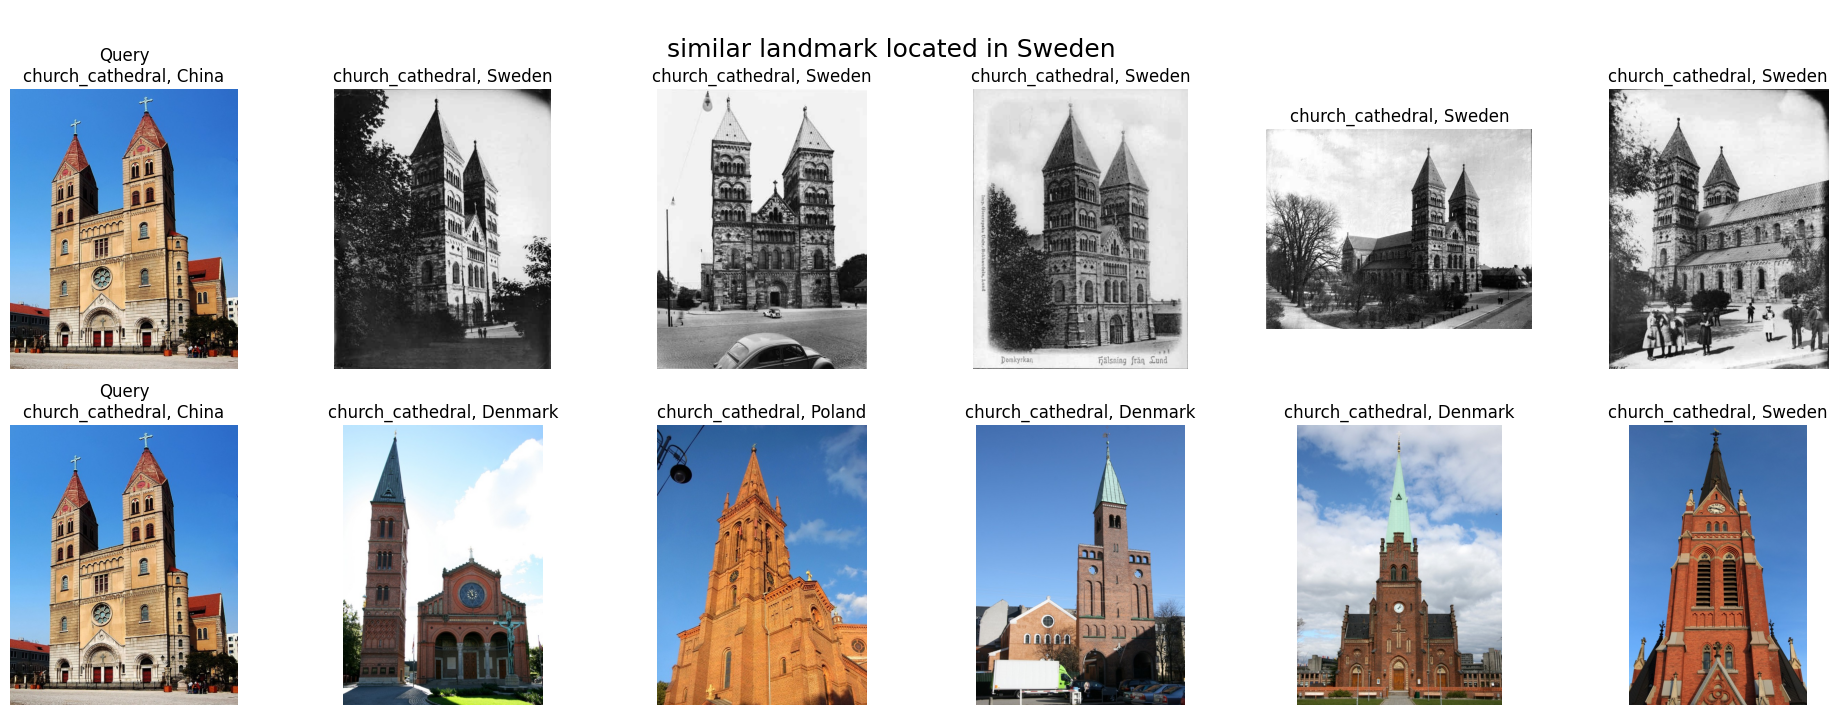

In [117]:
# viz
caption = test_set[12834]["caption"]
query = meta[query_img_ids[12834]]
label = [meta[gt] for gt in all_gt[12834][:5]]
pred = [meta[p] for p in [pred.item() for pred in all_pred[12834] if pred != query_img_ids[12834]][:5]]


fig, ax = plt.subplots(2, 6, figsize=(24, 8))
fig.suptitle(f"\n{caption}\n\n", fontsize=18)
for i in range(2):
    for j in range(6):
        if j == 0 and (i == 0 or i == 1):
            ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{query["id"]}.jpg")))
            ax[i, j].set_title(f"Query\n{query["category"]}, {query["country"]}")
        else:
            if i == 0:
                ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{label[j-1]["id"]}.jpg")))
                ax[i, j].set_title(f"{label[j-1]["category"]}, {label[j-1]["country"]}")
            if i == 1:
                ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{pred[j-1]["id"]}.jpg")))
                ax[i, j].set_title(f"{pred[j-1]["category"]}, {pred[j-1]["country"]}")
        ax[i, j].axis("off")


# plt.tight_layout()
plt.show()